# 06 — 1D-CNN Baseline
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Implement and evaluate a 1D Convolutional Neural Network as the deep learning baseline.
Unlike classical ML models and quantum models which operate on hand-crafted features,
the CNN learns directly from raw windowed physiological signals.

## Why Full Dataset (No Subsampling)?
CNNs are gradient-based and require sufficient data for stable training and
meaningful filter learning. 150 samples per class is too small for a CNN to
converge reliably. The full WESAD dataset is used here.
This is documented in methodology as a deliberate design decision.

## Architecture
```
Input (window_samples x n_channels)
  -> Conv1D(32, kernel=7) + BatchNorm + ReLU + MaxPool
  -> Conv1D(64, kernel=5) + BatchNorm + ReLU + MaxPool
  -> Conv1D(128, kernel=3) + BatchNorm + ReLU + AdaptiveAvgPool
  -> Flatten
  -> Linear(128) + Dropout(0.5)
  -> Linear(n_classes)
```

## Datasets & Tasks
| Dataset | Task      | Input                          |
|---------|-----------|--------------------------------|
| WESAD   | Binary    | Raw chest signals, 60s windows |
| WESAD   | 3-class   | Raw chest signals, 60s windows |

## Evaluation
Leave-One-Subject-Out (LOSO) — same protocol as classical baselines.

---


## 0. Configuration

In [29]:
import os, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

# ── SET THIS ──────────────────────────────────────────────────────────────────
WESAD_PATH = r"C:/Users/vPro/OneDrive - Al Akhawayn University in Ifrane/AUI/capstone/capstone/ml_pipeline/data/raw/WESAD" 
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '06_cnn_baseline_patched')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Subjects & labels ─────────────────────────────────────────────────────────
ALL_SUBJECTS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP    = {1: 'baseline', 2: 'stress', 3: 'amusement'}
BINARY_MAP   = {1: 0, 2: 1}
THREE_MAP    = {1: 0, 2: 1, 3: 2}

# ── Signal config ─────────────────────────────────────────────────────────────
FS           = 700
WINDOW_S     = 30
STEP_S       = 10
PURITY       = 0.80
WIN_SAMP     = WINDOW_S * FS
STEP_SAMP    = STEP_S   * FS

# Downsample to 100Hz before CNN input
FS_TARGET    = 100
DOWNSAMPLE_F = FS // FS_TARGET   # = 7
WIN_SAMP_DS  = WINDOW_S * FS_TARGET  # = 6000 samples

# Chest signals used as CNN input channels
# ACC is 3-axis so we use magnitude — gives 5 channels total
SIGNAL_NAMES = ['ECG', 'EDA', 'EMG', 'Resp', 'Temp']

# ── CNN training config ───────────────────────────────────────────────────────
EPOCHS       = 50
BATCH_SIZE   = 32
LR           = 3e-4   # was 3e-3 — too high, was collapsing to majority-class prediction
RANDOM_STATE = 42

# Subsample raw windows per subject per class for CNN
# (still uses full data compared to quantum — but caps per-subject imbalance)
MAX_WINDOWS_PER_CLASS = None   # None = use all windows

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Device     : {DEVICE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Window     : {WINDOW_S}s  Step: {STEP_S}s')
print(f'  Plots dir  : {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  Device     : cpu
  Epochs     : 50
  Batch size : 32
  Window     : 30s  Step: 10s
  Plots dir  : c:\Users\vPro\OneDrive\Desktop\kenza\research\Applied-Research\results\plots\06_cnn_baseline_patched


## 1. Raw Signal Extraction
Extract raw windowed signals from WESAD pickle files.
Each window becomes one sample: shape (n_channels, window_samples).

> **Update:** normalization moved from per-window to per-subject (see the FIX
> comment in the next cell). Per-window z-scoring was erasing the absolute
> level information (mean HR, mean EDA level, mean temp) that the classical
> baselines' engineered features rely on, which was the main suspect behind
> the CNN's earlier F1 of 0.39 (binary) / 0.23 (3-class) — far below every
> other model, including the hybrid CNN-QNN, on both WESAD tasks.

In [17]:
from scipy import signal as scipy_signal

def load_subject(wesad_path, sid):
    pkl = os.path.join(wesad_path, f'S{sid}', f'S{sid}.pkl')
    with open(pkl, 'rb') as f:
        return pickle.load(f, encoding='latin1')

def bandpass(sig, lo, hi, fs=700, order=4):
    nyq = fs / 2
    sos = scipy_signal.butter(order, [lo/nyq, hi/nyq], btype='band', output='sos')
    return scipy_signal.sosfiltfilt(sos, sig)

def lowpass(sig, cut, fs=700, order=4):
    nyq = fs / 2
    sos = scipy_signal.butter(order, cut/nyq, btype='low', output='sos')
    return scipy_signal.sosfiltfilt(sos, sig)

def get_window_label(lbl_win, purity=PURITY):
    valid = np.isin(lbl_win, [1, 2, 3])
    if valid.sum() / len(lbl_win) < purity:
        return -1
    from collections import Counter
    cnt = Counter(lbl_win[valid])
    maj_lbl, maj_cnt = cnt.most_common(1)[0]
    return maj_lbl if maj_cnt / len(lbl_win) >= purity else -1

def extract_raw_windows(wesad_path, sid, label_map):
    data   = load_subject(wesad_path, sid)
    labels = data['label']
    chest  = data['signal']['chest']

    # Preprocess signals
    ecg  = bandpass(np.array(chest['ECG']).flatten(), 0.5, 40.0)
    eda  = lowpass( np.array(chest['EDA']).flatten(), 1.0)
    emg  = bandpass(np.array(chest['EMG']).flatten(), 20.0, 340.0) \
           if 'EMG' in chest else np.zeros(len(ecg))
    resp = bandpass(np.array(chest['Resp']).flatten(), 0.1, 0.5)
    temp = np.array(chest['Temp']).flatten()

    # Downsample all signals from 700Hz to 100Hz
    signals = np.stack([ecg, eda, emg, resp, temp], axis=0)  # (5, n_samples)
    signals = signals[:, ::DOWNSAMPLE_F]                       # (5, n_samples//7)
    labels_ds = labels[::DOWNSAMPLE_F]                         # downsample labels too

    # ── FIX: normalize per SUBJECT, not per window ────────────────────────────
    # Standardizing each 30s window independently erases each window's absolute
    # level (mean HR, mean skin conductance level, mean temp) — exactly the
    # signal the classical features (ecg_mean_hr, eda_mean_scl, temp_mean, ...)
    # rely on to separate stress from baseline. Normalizing once per subject,
    # over their whole recording, keeps between-condition level shifts intact
    # while still standardizing units across subjects (so the CNN isn't
    # comparing raw mV/µS scales between people). This uses only this subject's
    # own signal, computed before any windowing/labeling, so it introduces no
    # leakage across LOSO folds.
    mu  = signals.mean(axis=1, keepdims=True)
    std = signals.std(axis=1,  keepdims=True) + 1e-8
    signals = (signals - mu) / std
    # ───────────────────────────────────────────────────────────────────────────

    WIN_SAMP_USE  = WIN_SAMP_DS
    STEP_SAMP_USE = WINDOW_S * FS_TARGET // 2   # 50% overlap at 100Hz

    X_wins, y_wins = [], []
    n = len(labels_ds)

    for start in range(0, n - WIN_SAMP_USE + 1, STEP_SAMP_USE):
        end       = start + WIN_SAMP_USE
        lbl_win   = labels_ds[start:end]
        win_label = get_window_label(lbl_win)

        if win_label not in label_map:
            continue

        win = signals[:, start:end]   # (5, 6000) — already subject-normalized above

        X_wins.append(win)
        y_wins.append(label_map[win_label])

    if len(X_wins) == 0:
        return np.empty((0, 5, WIN_SAMP_USE)), np.empty(0, dtype=int)

    return np.stack(X_wins).astype(np.float32), np.array(y_wins, dtype=np.int64)


print('Raw signal extraction functions defined.')
print(f'Output shape per subject: (n_windows, 5_channels, {WIN_SAMP}_samples)')

# Quick test on S2
print('\nTest extraction on S2...')
X_test, y_test = extract_raw_windows(WESAD_PATH, 2, BINARY_MAP)
print(f'  S2 binary: X={X_test.shape}  y={y_test.shape}  '
      f'labels={dict(Counter(y_test.tolist()))}')


Raw signal extraction functions defined.
Output shape per subject: (n_windows, 5_channels, 21000_samples)

Test extraction on S2...
  S2 binary: X=(114, 5, 3000)  y=(114,)  labels={0: 75, 1: 39}


## 2. CNN Architecture

In [20]:
class CNN1D(nn.Module):
    """
    1D Convolutional Neural Network for physiological signal classification.
    Input : (batch, n_channels, window_samples)
    Output: (batch, n_classes)
    """
    def __init__(self, n_channels=5, n_classes=2, dropout=0.5):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)   # global average pooling
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.classifier(x)


# Quick architecture check
_model = CNN1D(n_channels=5, n_classes=2)
_x     = torch.randn(4, 5, WIN_SAMP_DS)
_out   = _model(_x)
print(f'Architecture check: input={list(_x.shape)} -> output={list(_out.shape)}')
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
del _model, _x, _out


Architecture check: input=[4, 5, 3000] -> output=[4, 2]
Trainable parameters: 53,378


## 3. Training & Evaluation Utilities

In [21]:
from torch.utils.data import WeightedRandomSampler

def get_weighted_sampler(y):
    counts  = np.bincount(y)
    weights = 1.0 / counts[y]
    weights = torch.tensor(weights, dtype=torch.float32)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def get_class_weights(y, n_classes, device):
    """Compute inverse-frequency class weights for imbalanced data."""
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        # FIX: clip gradients — cheap insurance against the instability that
        # was likely driving training into the trivial "always predict the
        # majority class" solution at the old, higher learning rate.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds = out.argmax(1)
            correct += (preds == y_batch).sum().item()
            total   += len(y_batch)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_true.extend(y_batch.cpu().numpy().tolist())
    return total_loss/total, correct/total, all_preds, all_true


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


print('Training utilities defined.')


Training utilities defined.


## 4. LOSO Pipeline
> This section loads raw windows for all subjects and runs LOSO.
> Expect 5-15 minutes depending on your hardware.

In [22]:
from tqdm.auto import tqdm

def run_cnn_loso(wesad_path, subjects, label_map, task_name,
                 n_classes, epochs=EPOCHS, batch_size=BATCH_SIZE,
                 lr=LR, average='macro'):
    """
    LOSO cross-validation for the 1D-CNN.
    Loads raw windows per subject, trains from scratch each fold.
    """
    fold_rows   = []
    cm_accum    = np.zeros((n_classes, n_classes), dtype=int)
    train_curves= []   # list of (fold, epoch, train_loss, train_acc)

    print(f'\n=== {task_name} — CNN LOSO ({len(subjects)} folds) ===')
    print(f'    Epochs={epochs}  BS={batch_size}  LR={lr}  Device={DEVICE}')

    # Pre-load all subjects
    print('  Pre-loading all subjects...')
    subject_data = {}
    for sid in tqdm(subjects, desc='Loading'):
        X, y = extract_raw_windows(wesad_path, sid, label_map)
        subject_data[sid] = (X, y)
        print(f'    S{sid}: {X.shape[0]} windows  {dict(Counter(y.tolist()))}')

    for fold_i, test_sid in enumerate(subjects):
        # Build train/test splits
        X_train_list, y_train_list = [], []
        for sid in subjects:
            if sid == test_sid:
                continue
            X_s, y_s = subject_data[sid]
            if len(X_s) > 0:
                X_train_list.append(X_s)
                y_train_list.append(y_s)

        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test, y_test = subject_data[test_sid]

        if len(X_test) == 0:
            print(f'  Fold {fold_i+1}: S{test_sid} has no valid windows — skipping')
            continue

        # Class weights for imbalance
        criterion = nn.CrossEntropyLoss()

        # DataLoaders
        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long))
        test_ds  = TensorDataset(
            torch.tensor(X_test,  dtype=torch.float32),
            torch.tensor(y_test,  dtype=torch.long))
        sampler      = get_weighted_sampler(y_train)
        train_loader = DataLoader(train_ds, batch_size=batch_size,
                                  sampler=sampler, drop_last=False)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                                  shuffle=False, drop_last=False)

        # Fresh model each fold
        model     = CNN1D(n_channels=5, n_classes=n_classes).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

        t0 = time.time()
        for epoch in range(epochs):
            tr_loss, tr_acc = train_epoch(
                model, train_loader, optimizer, criterion, DEVICE)
            scheduler.step()
            train_curves.append({
                'fold': fold_i+1, 'epoch': epoch+1,
                'train_loss': tr_loss, 'train_acc': tr_acc
            })
        train_time = time.time() - t0

        # Evaluate
        t1 = time.time()
        _, _, y_pred, y_true = eval_epoch(
            model, test_loader, criterion, DEVICE)
        test_time = time.time() - t1

        metrics = compute_metrics(y_true, y_pred, average=average)
        classes = sorted(label_map.values())
        cm      = confusion_matrix(y_true, y_pred, labels=classes)
        cm_accum += cm

        fold_rows.append({
            'task'        : task_name,
            'model'       : '1D-CNN',
            'fold'        : fold_i + 1,
            'test_subject': int(test_sid),
            'train_size'  : len(y_train),
            'test_size'   : len(y_test),
            'train_time'  : round(train_time, 2),
            'test_time'   : round(test_time, 4),
            **metrics
        })

        print(f'  Fold {fold_i+1:2d}/{len(subjects)} '
              f'test=S{test_sid:2d}  '
              f'acc={metrics["accuracy"]:.3f}  '
              f'f1={metrics["f1"]:.3f}  '
              f'train={train_time:.0f}s')

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return (pd.DataFrame(fold_rows),
            cm_accum,
            pd.DataFrame(train_curves))


print('CNN LOSO pipeline defined.')


CNN LOSO pipeline defined.


## 5. WESAD Binary Task
> Trains 15 CNN models (one per LOSO fold). Expect 10–20 minutes.

In [25]:
results_bin, cm_bin, curves_bin = run_cnn_loso(
    wesad_path = WESAD_PATH,
    subjects   = ALL_SUBJECTS,
    label_map  = BINARY_MAP,
    task_name  = 'WESAD_binary_CNN',
    n_classes  = 2,
    average    = 'macro'
)

print('\n=== WESAD Binary CNN — Mean Metrics ===')
print(results_bin[['accuracy','precision','recall','f1',
                    'train_time','test_time']].mean().round(4).to_string())
print(f'\nStd F1: {results_bin["f1"].std():.4f}')



=== WESAD_binary_CNN — CNN LOSO (15 folds) ===
    Epochs=50  BS=32  LR=0.0003  Device=cpu
  Pre-loading all subjects...


Loading:   7%|▋         | 1/15 [00:05<01:23,  5.94s/it]

    S2: 114 windows  {0: 75, 1: 39}


Loading:  13%|█▎        | 2/15 [00:12<01:18,  6.07s/it]

    S3: 115 windows  {0: 74, 1: 41}


...

Loading:  93%|█████████▎| 14/15 [02:00<00:10, 10.41s/it]

    S16: 120 windows  {0: 77, 1: 43}


Loading: 100%|██████████| 15/15 [02:11<00:00,  8.77s/it]

    S17: 125 windows  {0: 78, 1: 47}


  Fold  1/15 test=S 2  acc=0.939  f1=0.934  train=660s
  Fold  2/15 test=S 3  acc=0.878  f1=0.873  train=662s
  Fold  3/15 test=S 4  acc=1.000  f1=1.000  train=691s
  Fold  4/15 test=S 5  acc=0.983  f1=0.981  train=590s
  Fold  5/15 test=S 6  acc=0.866  f1=0.838  train=424s
  Fold  6/15 test=S 7  acc=1.000  f1=1.000  train=424s
  Fold  7/15 test=S 8  acc=0.605  f1=0.599  train=396s
  Fold  8/15 test=S 9  acc=0.892  f1=0.870  train=511s
  Fold  9/15 test=S10  acc=0.832  f1=0.831  train=492s
  Fold 10/15 test=S11  acc=1.000  f1=1.000  train=520s
  Fold 11/15 test=S13  acc=1.000  f1=1.000  train=515s
  Fold 12/15 test=S14  acc=1.000  f1=1.000  train=518s
  Fold 13/15 test=S15  acc=1.000  f1=1.000  train=463s
  Fold 14/15 test=S16  acc=1.000  f1=1.000  train=488s
  Fold 15/15 test=S17  acc=1.000  f1=1.000  train=518s

=== WESAD Binary CNN — Mean Metrics ===
accuracy        0.9330
precision       0.9461
recall          0.9360
f1              0.9285
train_time    524.7267
test_time       0.2

## 6. WESAD 3-Class Task

In [27]:
results_3cl, cm_3cl, curves_3cl = run_cnn_loso(
    wesad_path = WESAD_PATH,
    subjects   = ALL_SUBJECTS,
    label_map  = THREE_MAP,
    task_name  = 'WESAD_3class_CNN',
    n_classes  = 3,
    average    = 'macro'
)

print('\n=== WESAD 3-Class CNN — Mean Metrics ===')
print(results_3cl[['accuracy','precision','recall','f1',
                     'train_time','test_time']].mean().round(4).to_string())
print(f'\nStd F1: {results_3cl["f1"].std():.4f}')



=== WESAD_3class_CNN — CNN LOSO (15 folds) ===
    Epochs=50  BS=32  LR=0.0003  Device=cpu
  Pre-loading all subjects...


Loading:   7%|▋         | 1/15 [00:11<02:39, 11.38s/it]

    S2: 137 windows  {0: 75, 1: 39, 2: 23}


Loading:  13%|█▎        | 2/15 [00:23<02:33, 11.82s/it]

    S3: 138 windows  {0: 74, 1: 41, 2: 23}


...

Loading:  93%|█████████▎| 14/15 [02:13<00:07,  7.51s/it]

    S16: 143 windows  {0: 77, 1: 43, 2: 23}


Loading: 100%|██████████| 15/15 [02:21<00:00,  9.42s/it]

    S17: 149 windows  {0: 78, 2: 24, 1: 47}


  Fold  1/15 test=S 2  acc=0.657  f1=0.605  train=686s
  Fold  2/15 test=S 3  acc=0.746  f1=0.726  train=602s
  Fold  3/15 test=S 4  acc=0.496  f1=0.532  train=633s
  Fold  4/15 test=S 5  acc=0.979  f1=0.979  train=670s
  Fold  5/15 test=S 6  acc=0.888  f1=0.876  train=578s
  Fold  6/15 test=S 7  acc=0.944  f1=0.927  train=694s
  Fold  7/15 test=S 8  acc=0.648  f1=0.642  train=674s
  Fold  8/15 test=S 9  acc=0.699  f1=0.482  train=669s
  Fold  9/15 test=S10  acc=0.826  f1=0.615  train=594s
  Fold 10/15 test=S11  acc=0.917  f1=0.903  train=585s
  Fold 11/15 test=S13  acc=0.897  f1=0.800  train=614s
  Fold 12/15 test=S14  acc=0.828  f1=0.691  train=695s
  Fold 13/15 test=S15  acc=0.834  f1=0.764  train=665s
  Fold 14/15 test=S16  acc=0.979  f1=0.966  train=602s
  Fold 15/15 test=S17  acc=0.879  f1=0.766  train=579s

=== WESAD 3-Class CNN — Mean Metrics ===
accuracy        0.8145
precision       0.7894
recall          0.7853
f1              0.7515
train_time    636.1747
test_time       0.

## 7. Results & Plots

In [28]:
all_cnn = pd.concat([results_bin, results_3cl], ignore_index=True)

summary_cnn = (
    all_cnn.groupby('task')
    .agg(
        accuracy_mean  = ('accuracy',   'mean'),
        accuracy_std   = ('accuracy',   'std'),
        precision_mean = ('precision',  'mean'),
        recall_mean    = ('recall',     'mean'),
        f1_mean        = ('f1',         'mean'),
        f1_std         = ('f1',         'std'),
        train_time_mean= ('train_time', 'mean'),
        test_time_mean = ('test_time',  'mean'),
    )
    .round(4)
    .reset_index()
)
summary_cnn['model'] = '1D-CNN'

print('=== 1D-CNN SUMMARY ===')
print(summary_cnn.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'cnn_baseline_summary_patched.csv')
summary_cnn.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'cnn_baseline_per_fold_patched.csv')
all_cnn.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== 1D-CNN SUMMARY ===
            task  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean  test_time_mean  model
WESAD_3class_CNN         0.8145        0.1389          0.7894       0.7853   0.7515  0.1574         636.1747          0.3242 1D-CNN
WESAD_binary_CNN         0.9330        0.1087          0.9461       0.9360   0.9285  0.1122         524.7267          0.2214 1D-CNN

Saved: ..\results\output_data\cnn_baseline_summary_patched.csv
Saved: ..\results\output_data\cnn_baseline_per_fold_patched.csv


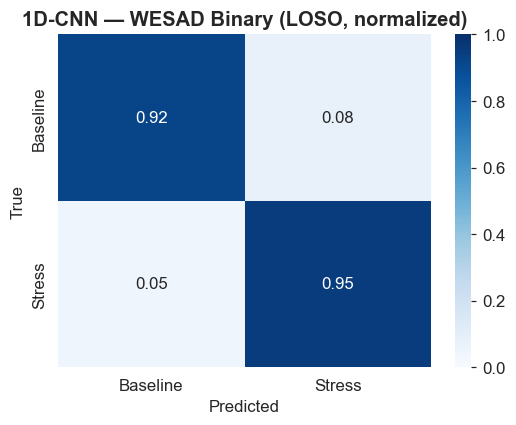

Saved: ..\results\plots\06_cnn_baseline_patched\cm_cnn_wesad_binary.png


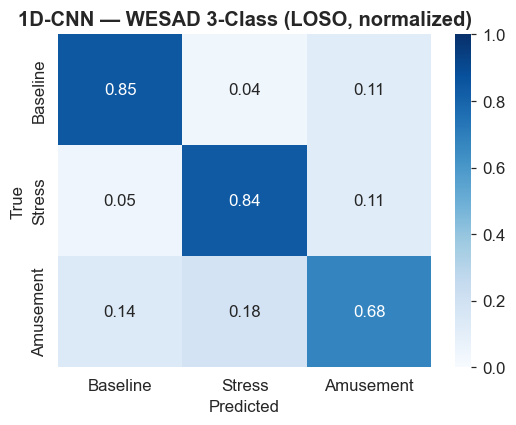

Saved: ..\results\plots\06_cnn_baseline_patched\cm_cnn_wesad_3class.png


In [30]:
# Confusion matrices
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(cm_bin, ['Baseline','Stress'],
        '1D-CNN — WESAD Binary (LOSO, normalized)',
        os.path.join(PLOTS_DIR, 'cm_cnn_wesad_binary.png'))

plot_cm(cm_3cl, ['Baseline','Stress','Amusement'],
        '1D-CNN — WESAD 3-Class (LOSO, normalized)',
        os.path.join(PLOTS_DIR, 'cm_cnn_wesad_3class.png'))


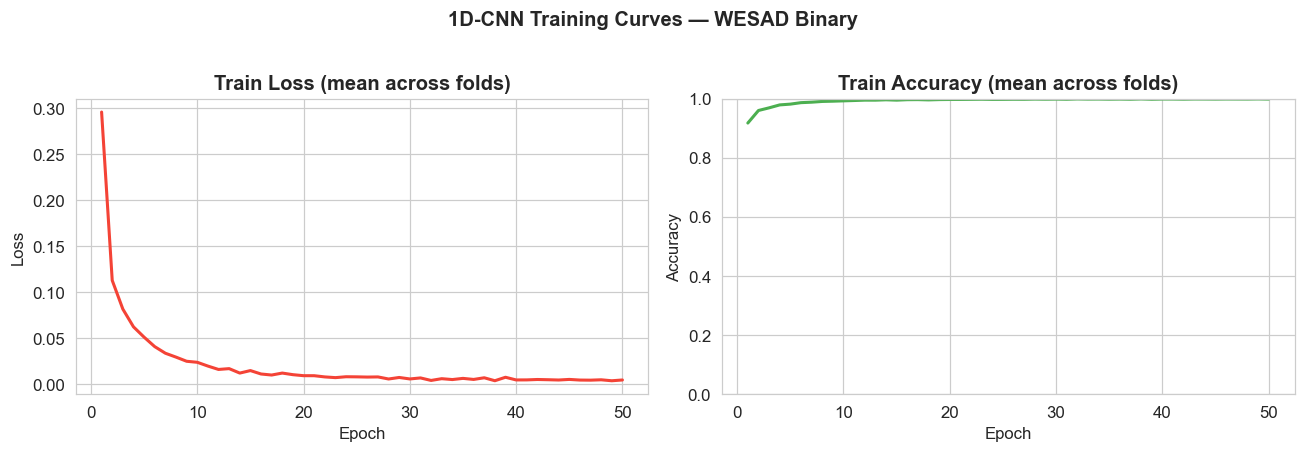

Saved: ..\results\plots\06_cnn_baseline_patched\curves_cnn_wesad_binary.png


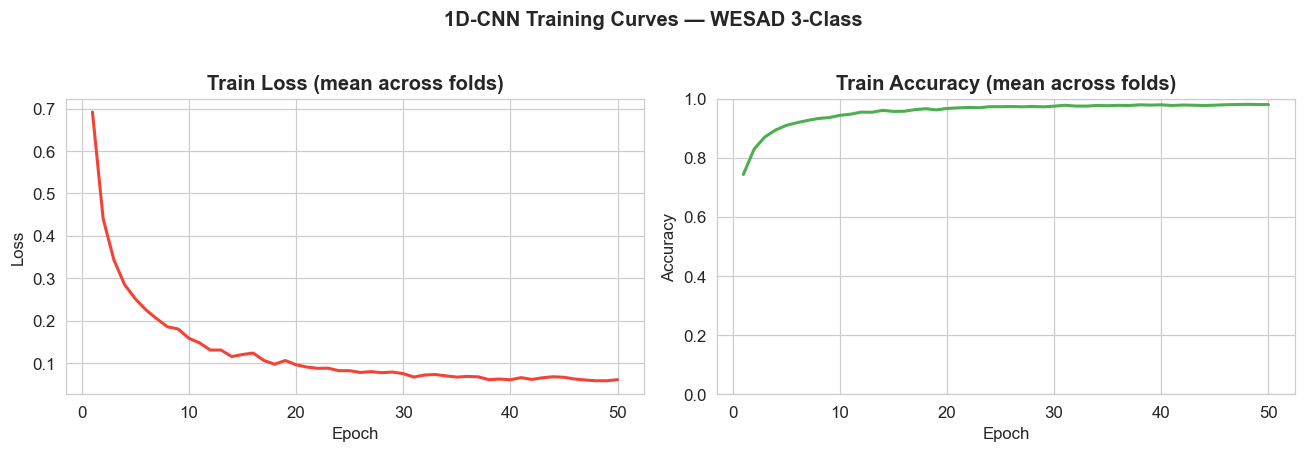

Saved: ..\results\plots\06_cnn_baseline_patched\curves_cnn_wesad_3class.png


In [31]:
# Training curves — average across folds
for curves, task_label, fname in [
        (curves_bin, 'WESAD Binary', 'curves_cnn_wesad_binary.png'),
        (curves_3cl, 'WESAD 3-Class','curves_cnn_wesad_3class.png')]:

    mean_curves = curves.groupby('epoch')[['train_loss','train_acc']].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(mean_curves.index, mean_curves['train_loss'],
                 color='#F44336', lw=2)
    axes[0].set_title('Train Loss (mean across folds)', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(mean_curves.index, mean_curves['train_acc'],
                 color='#4CAF50', lw=2)
    axes[1].set_title('Train Accuracy (mean across folds)', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)

    plt.suptitle(f'1D-CNN Training Curves — {task_label}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, fname)
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')


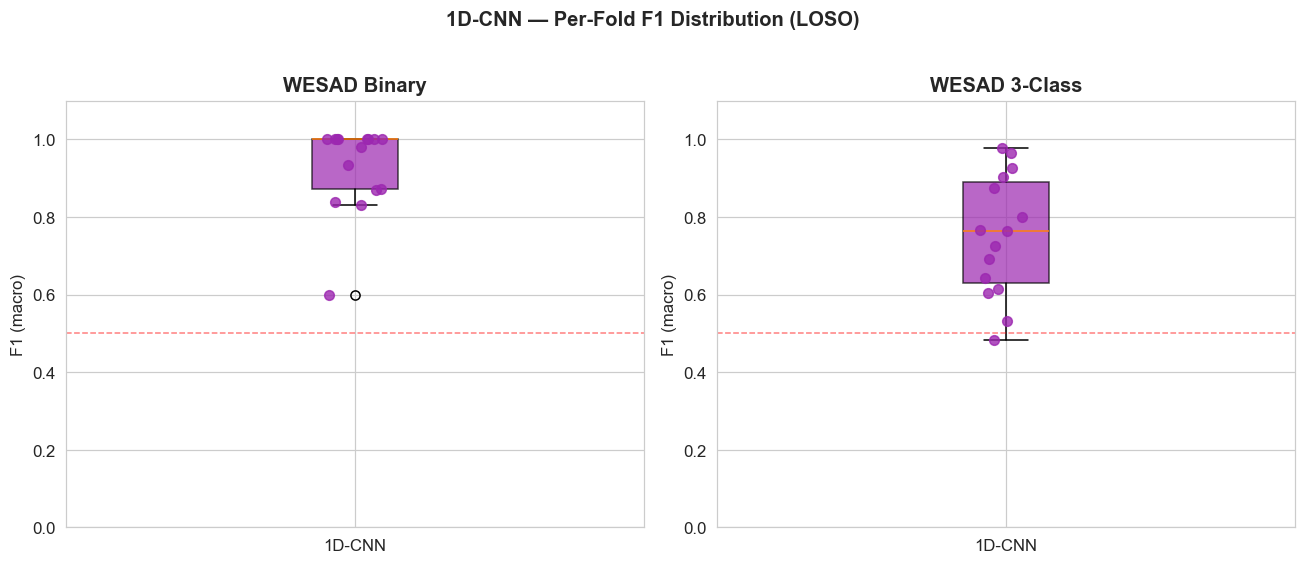

Saved: ..\results\plots\06_cnn_baseline_patched\cnn_f1_per_fold_boxplot.png


In [32]:
# Per-fold F1 boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (task_key, task_label) in zip(axes, [
        ('WESAD_binary_CNN','WESAD Binary'),
        ('WESAD_3class_CNN','WESAD 3-Class')]):
    td = all_cnn[all_cnn['task']==task_key]['f1'].values
    ax.boxplot([td], patch_artist=True, labels=['1D-CNN'],
               boxprops=dict(facecolor='#9C27B0', alpha=0.7))
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)
    # Overlay individual fold points
    ax.scatter(np.ones(len(td)) + np.random.uniform(-0.05,0.05,len(td)),
               td, color='#9C27B0', alpha=0.8, zorder=3, s=40)
plt.suptitle('1D-CNN — Per-Fold F1 Distribution (LOSO)',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'cnn_f1_per_fold_boxplot.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


In [33]:
# 3-class overlap: stress vs amusement
print('=== 1D-CNN: Stress/Amusement Confusion (WESAD 3-class) ===')
cm = cm_3cl
total_stress = cm[1, :].sum()
total_amuse  = cm[2, :].sum()
s_a = cm[1, 2] / total_stress if total_stress > 0 else 0
a_s = cm[2, 1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

overlap_cnn = pd.DataFrame([{
    'model'                  : '1D-CNN',
    'stress->amusement_rate' : round(s_a, 4),
    'amusement->stress_rate' : round(a_s, 4),
}])
p = os.path.join(OUTPUT_DATA_DIR, 'cnn_stress_amusement_overlap_patched.csv')
overlap_cnn.to_csv(p, index=False)
print(f'Saved: {p}')


=== 1D-CNN: Stress/Amusement Confusion (WESAD 3-class) ===
  Stress -> Amusement : 74/644 (11.5%)
  Amusement -> Stress : 65/353  (18.4%)
Saved: ..\results\output_data\cnn_stress_amusement_overlap_patched.csv


## 8. Summary Log

In [34]:
summary_dict = {
    'notebook'      : '06_cnn_baseline_patched',
    'timestamp'     : datetime.now().isoformat(),
    'architecture'  : {
        'type'      : '1D-CNN',
        'n_channels': 5,
        'blocks'    : ['Conv1d(32,k7)+BN+ReLU+MaxPool4',
                       'Conv1d(64,k5)+BN+ReLU+MaxPool4',
                       'Conv1d(128,k3)+BN+ReLU+AdaptiveAvgPool',
                       'Linear(128)+Dropout(0.5)+Linear(n_classes)'],
    },
    'training'      : {
        'epochs'    : EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr'        : LR,
        'optimizer' : 'Adam + weight_decay=1e-4',
        'scheduler' : 'StepLR(step=10, gamma=0.5)',
        'data'      : 'Full dataset (no subsampling)',
        'justification': 'CNN requires sufficient data for stable gradient training'
    },
    'evaluation'    : 'LOSO',
    'results'       : {}
}

for _, row in summary_cnn.iterrows():
    summary_dict['results'][row['task']] = {
        'accuracy_mean': row['accuracy_mean'],
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'train_time_s' : row['train_time_mean'],
    }

summary_dict['next'] = '07_qsvm_experiments.ipynb'

p = os.path.join(LOGS_DIR, '06_cnn_baseline_patched_summary.json')
with open(p,'w') as f: json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('CNN BASELINE COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


CNN BASELINE COMPLETE
{
  "notebook": "06_cnn_baseline_patched",
  "timestamp": "2026-09-29T14:51:22.066736",
  "architecture": {
    "type": "1D-CNN",
    "n_channels": 5,
    "blocks": [
      "Conv1d(32,k7)+BN+ReLU+MaxPool4",
      "Conv1d(64,k5)+BN+ReLU+MaxPool4",
      "Conv1d(128,k3)+BN+ReLU+AdaptiveAvgPool",
      "Linear(128)+Dropout(0.5)+Linear(n_classes)"
    ]
  },
  "training": {
    "epochs": 50,
    "batch_size": 32,
    "lr": 0.0003,
    "optimizer": "Adam + weight_decay=1e-4",
    "scheduler": "StepLR(step=10, gamma=0.5)",
    "data": "Full dataset (no subsampling)",
    "justification": "CNN requires sufficient data for stable gradient training"
  },
  "evaluation": "LOSO",
  "results": {
    "WESAD_3class_CNN": {
      "accuracy_mean": 0.8145,
      "f1_mean": 0.7515,
      "f1_std": 0.1574,
      "train_time_s": 636.1747
    },
    "WESAD_binary_CNN": {
      "accuracy_mean": 0.933,
      "f1_mean": 0.9285,
      "f1_std": 0.1122,
      "train_time_s": 524.7267
    }